In [26]:
#import relevant libraries: pip install re, pip install natsort, pip install plotly==5.10.0
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import dabest
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [27]:

openPath = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\Fecundity\\"

files = os.listdir(openPath)
filename = openPath + "Toxicity_raw data.csv"

dfe=pd.read_csv(filename)

In [28]:
df = pd.concat([dfe['Genotype'], dfe['Hatched'], dfe['Eclosed']], axis = 1)

if df['Genotype'].str.contains(" ACR").any():
   df['Genotype'] = df['Genotype'].str.replace(" ACR", " GtACR1")
   
if df['Genotype'].str.contains("[ATR]").any():
   df['Genotype'] = df['Genotype'].str.replace(" [ATR]", "*")

df['number'] = pd.factorize(df.Genotype)[0].tolist()

repeats = int(df[df.number == 1].number.value_counts().values[0])

In [29]:
dftotal = pd.DataFrame()
dfnumbers = pd.DataFrame()
for n in df['Genotype'].unique():
    df1 = pd.DataFrame()
    df2 = pd.DataFrame()
    embryos = int(df[df['Genotype'] == n]['Hatched'].sum())
    eclosed = int(df[df['Genotype'] == n]['Eclosed'].sum())
    
    #total embryos
    df1[n+" (H)"] = [1]*embryos
    df2[n+"_embryos"] = [embryos]
    
    #total pupate
    failpupate =embryos-eclosed                        
    df1[n + " (E)"] = [0]*failpupate + [1]*eclosed 
    df2[n + "_eclose"] = [eclosed]
    
    df1['ID'] = range(1, len(df1)+1)
    # dftotal = pd.concat([dftotal,df1], axis =1).reset_index(drop = True)
    dfnumbers = pd.concat([dfnumbers,df2], axis =1).reset_index(drop = True)
    
    dfmelted = pd.melt(df1, id_vars = ["ID"], value_vars=df1.columns[:-1])

    dftotal = pd.concat([dfmelted, dftotal], axis = 0).reset_index(drop = True)
    

dftotal['lethality'] = dftotal['value'] = 1 - dftotal['value']

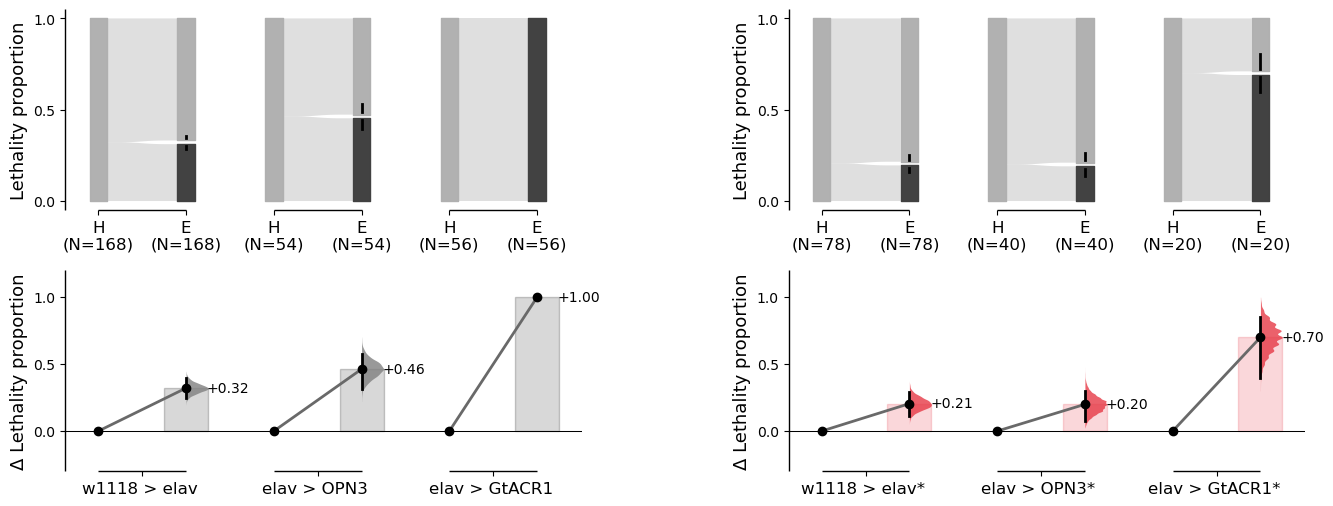

In [30]:
from matplotlib.collections import PolyCollection

multi_groups_baseline_1 = dabest.load(dftotal, idx=(("w1118 x elav (H)", 'w1118 x elav (E)' )
                                                    ,("elav x OPN3 (H)", 'elav x OPN3 (E)')
                                                    ,("elav x GtACR1 (H)", 'elav x GtACR1 (E)')), x = "variable", y = "lethality",
                                          proportional=True, paired="baseline", id_col="ID")

multi_groups_baseline_2 = dabest.load(dftotal, idx=(("w1118 x elav* (H)", 'w1118 x elav* (E)' )
                                                    ,("elav x OPN3* (H)", 'elav x OPN3* (E)')
                                                    ,("elav x GtACR1* (H)", 'elav x GtACR1* (E)')), x = "variable", y = "lethality",
                                          proportional=True, paired="baseline", id_col="ID")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.4})

color_trans = "#404040"      # dark gray — for all raw (top) bars
color_light_gray = "#B0B0B0" # for the WT contrast bar
color_red = "#E63946"

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 6}


def style_lethality_subplot(ax_raw, dabest_obj, contrast_color, outline_violin_color=None):
    dabest_obj.mean_diff.plot(custom_palette={0: color_light_gray, 1: color_trans},
        contrast_ylim=(-0.3, 1.2), ax=ax_raw, **common_style)
    contrast_ax = ax_raw.contrast_axes

    contrast_bars = [p for p in contrast_ax.patches if hasattr(p, 'get_height')]
    for i, p in enumerate(contrast_bars):
        p.set_facecolor(contrast_color)
        if outline_violin_color is not None:
            p.set_edgecolor(outline_violin_color)

    if outline_violin_color is not None:
        for col in contrast_ax.collections:
            if isinstance(col, PolyCollection):
                col.set_facecolor(outline_violin_color)
                col.set_edgecolor(outline_violin_color)

    ax_raw.set_ylabel('Lethality proportion')
    contrast_ax.set_ylabel('Δ Lethality proportion')

    results = dabest_obj.mean_diff.results
    n1 = results.loc[0, 'control_N']
    n2 = results.loc[1, 'control_N']
    n3 = results.loc[2, 'control_N']
    gen1 = results.loc[0, "control"].split("(")[0].replace("x", ">")
    gen2 = results.loc[1, "control"].split("(")[0].replace("x", ">")
    gen3 = results.loc[2, "control"].split("(")[0].replace("x", ">")

    contrast_ax.spines['bottom'].set_visible(False)
    contrast_ax.set_xticks([0.5, 2.5, 4.5])
    ax_raw.set_xticklabels([f"H\n(N={n1})", f"E\n(N={n1})",
                            f"H\n(N={n2})", f"E\n(N={n2})",
                            f"H\n(N={n3})", f"E\n(N={n3})"], fontsize=12)
    contrast_ax.set_xticklabels([gen1, gen2, gen3], fontsize=12)

    ax_raw.set_yticks([0.0, 0.5, 1.0])
    contrast_ax.set_yticks([0.0, 0.5, 1.0])


style_lethality_subplot(axes[0], multi_groups_baseline_1, color_trans)
style_lethality_subplot(axes[1], multi_groups_baseline_2, color_red, outline_violin_color=color_red)

mpl.rcParams['svg.fonttype'] = 'none'
plt.show()